In [1]:
import sys
vrae_path = r'C:\Users\achfr\timeseries-clustering-vae'
if vrae_path not in sys.path:
    sys.path.append(vrae_path)
from vrae.vrae import VRAE
from vrae.utils import *
import numpy as np
import torch
import pandas as pd
import plotly
from torch.utils.data import TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import sys
import numpy as np
import optuna
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import trange    
import joblib
import os

In [4]:
# 1D CNN Autoencoder + Optuna hyperparameter search
import sys
import numpy as np
import optuna
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import trange    
import joblib
import os

X_train = np.load(fr'C:\Users\achfr\single_cell_time_series_representation_learning\saved_training_sets\X_train_growth_antibiotic.npy', allow_pickle=True)
y_train = np.load(fr'C:\Users\achfr\single_cell_time_series_representation_learning\saved_training_sets\y_train_growth_antibiotic.npy', allow_pickle=True)
X_test = np.load(fr'C:\Users\achfr\single_cell_time_series_representation_learning\saved_training_sets\X_test_growth_antibiotic.npy', allow_pickle=True)
y_test = np.load(fr'C:\Users\achfr\single_cell_time_series_representation_learning\saved_training_sets\y_test_growth_antibiotic.npy', allow_pickle=True)

print('X_train shape\t',X_train.shape,'\t X_test shape\t',X_test.shape)

train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_dataset = TensorDataset(torch.from_numpy(X_test))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device ->', device)

# Access the tensor inside the existing TensorDataset `train_dataset`
X = train_dataset.tensors[0].detach().cpu().float() if hasattr(train_dataset, 'tensors') else torch.stack([t for t in train_dataset]).cpu().float()
# Ensure shape (N, C, L) for Conv1d: if (N, L) -> (N,1,L)
if X.dim() == 2:
    X = X.unsqueeze(1)
X.permute(0,2,1)
N, C, L = X.shape
print('Data shape (N,C,L):', X.shape)

# Helper: recreate TensorDataset on CPU for DataLoader (we will move batches to device)
full_dataset = TensorDataset(X)

class CNN1DAutoencoder(nn.Module):
    def __init__(self, in_channels, input_length, n_filters=16, kernel_size=3, latent_dim=16):
        super().__init__()  
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, n_filters, kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.Conv1d(n_filters, n_filters, kernel_size, padding=kernel_size//2),
            nn.ReLU()
        )
        # run a dummy forward to compute flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, input_length)
            enc_out = self.encoder(dummy)
        self.enc_shape = enc_out.shape[1:]  # (channels, length)
        enc_flat = enc_out.numel() // enc_out.shape[0]
        self.fc_enc = nn.Linear(enc_flat, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, enc_flat)
        # final conv to map back to original channels
        self.decoder_conv = nn.Sequential(
            nn.Conv1d(self.enc_shape[0], in_channels, kernel_size, padding=kernel_size//2)
        )
    def forward(self, x):
        enc = self.encoder(x)
        flat = enc.view(enc.size(0), -1)
        z = self.fc_enc(flat)
        dec_flat = self.fc_dec(z)
        dec = dec_flat.view(-1, *self.enc_shape)
        out = self.decoder_conv(dec)
        return out

    def encode(self, x):
        enc = self.encoder(x)
        flat = enc.view(enc.size(0), -1)
        z = self.fc_enc(flat)
        return z

def make_dataloaders(dataset, batch_size, val_fraction=0.2):
    n_val = max(1, int(len(dataset) * val_fraction))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
    return train_loader, val_loader

def train_epoch(model, loader, opt, criterion):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
        opt.zero_grad()
        out = model(x)
        loss = criterion(out, x)
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
            out = model(x)
            loss = criterion(out, x)
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

# Optuna objective
def objective(trial):
    # hyperparameters to tune
    n_filters = trial.suggest_categorical('n_filters', [8, 16, 32, 64])
    kernel_size = trial.suggest_categorical('kernel_size', [3,5,7])
    latent_dim = trial.suggest_int('latent_dim', 4, 64, log=True)
    lr = trial.suggest_float('lr', 1e-4, 1e-2)
    weight_decay = trial.suggest_float('weight_decay', 1e-8, 1e-3)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs = 50

    train_loader, val_loader = make_dataloaders(full_dataset, batch_size)
    model = CNN1DAutoencoder(in_channels=C, input_length=L, n_filters=n_filters, kernel_size=kernel_size, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val = float('inf')
    patience = 4
    wait = 0
    for ep in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss = eval_epoch(model, val_loader, criterion)
        trial.report(val_loss, ep)
        if trial.should_prune():
            raise optuna.TrialPruned()
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    return best_val

X_train shape	 (57607, 72, 1) 	 X_test shape	 (699, 72, 1)
device -> cuda
Data shape (N,C,L): torch.Size([57607, 72, 1])


In [5]:
# Run study (adjust n_trials as desired)
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=30, timeout=None)
print('Best value:', study.best_value)
print('Best params:', study.best_params)

# Train a final model with best params on full training data and save
best = study.best_params
best_model = CNN1DAutoencoder(in_channels=C, input_length=L, n_filters=best['n_filters'], kernel_size=best['kernel_size'], latent_dim=best['latent_dim']).to(device)
best_opt = torch.optim.Adam(best_model.parameters(), lr=best['lr'], weight_decay=best['weight_decay'])
criterion = nn.MSELoss()
# use a larger batch for final training
train_loader = DataLoader(full_dataset, batch_size=best.get('batch_size',64), shuffle=True, pin_memory=True)
for ep in trange(50, desc='Final training'):
    train_loss = train_epoch(best_model, train_loader, best_opt, criterion)

# save model
os.makedirs('model_CNN_optuna', exist_ok=True)
save_path = os.path.join('model_CNN_optuna','best_cnn1d_ae.pth')
torch.save({'model_state_dict': best_model.state_dict(), 'params': study.best_params}, save_path)
print('Saved best model to', save_path)

#save study
study_path = os.path.join('model_CNN_optuna','optuna_study.pkl')
joblib.dump(study, study_path)
print('Saved study to', study_path)

# import best configuration
model_state, params = torch.load(r'C:\Users\achfr\timeseries-clustering-vae\model_CNN_optuna\best_cnn1d_ae.pth')
best_model = CNN1DAutoencoder(in_channels=C, input_length=L, n_filters=params['n_filters'], kernel_size=params['kernel_size'], latent_dim=params['latent_dim']).to(device)
best_model.load_state_dict(model_state)
best_model.eval()

[I 2026-06-29 23:09:15,443] A new study created in memory with name: no-name-2e616c06-2711-4b36-ba78-88f292739142
[I 2026-06-29 23:09:50,149] Trial 0 finished with value: 0.4001181670262079 and parameters: {'n_filters': 16, 'kernel_size': 3, 'latent_dim': 33, 'lr': 0.0011258287219356345, 'weight_decay': 0.0007363960103213531, 'batch_size': 128}. Best is trial 0 with value: 0.4001181670262079.
[I 2026-06-29 23:10:37,950] Trial 1 finished with value: 0.5768438514689689 and parameters: {'n_filters': 16, 'kernel_size': 5, 'latent_dim': 6, 'lr': 0.00566646733644771, 'weight_decay': 0.0007416041701106953, 'batch_size': 32}. Best is trial 0 with value: 0.4001181670262079.
[I 2026-06-29 23:11:01,144] Trial 2 finished with value: 0.44180034721707856 and parameters: {'n_filters': 16, 'kernel_size': 3, 'latent_dim': 11, 'lr': 0.009253614691519866, 'weight_decay': 0.0003371188635355945, 'batch_size': 128}. Best is trial 0 with value: 0.4001181670262079.
[I 2026-06-29 23:11:34,859] Trial 3 finished

Best value: 0.10718984449088764
Best params: {'n_filters': 64, 'kernel_size': 3, 'latent_dim': 30, 'lr': 0.0017588364431364333, 'weight_decay': 1.4844092020937672e-06, 'batch_size': 128}


Final training:   0%|          | 0/50 [00:00<?, ?it/s]

Saved best model to model_CNN_optuna\best_cnn1d_ae.pth
Saved study to model_CNN_optuna\optuna_study.pkl


TypeError: string indices must be integers

Final training:   0%|          | 0/50 [00:00<?, ?it/s]

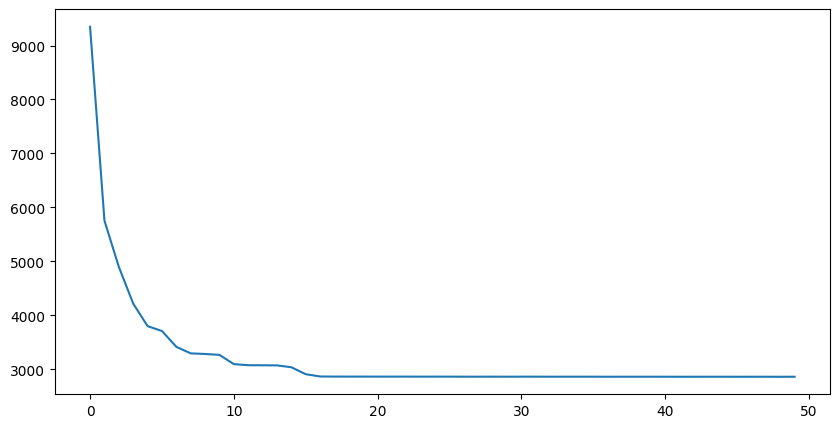

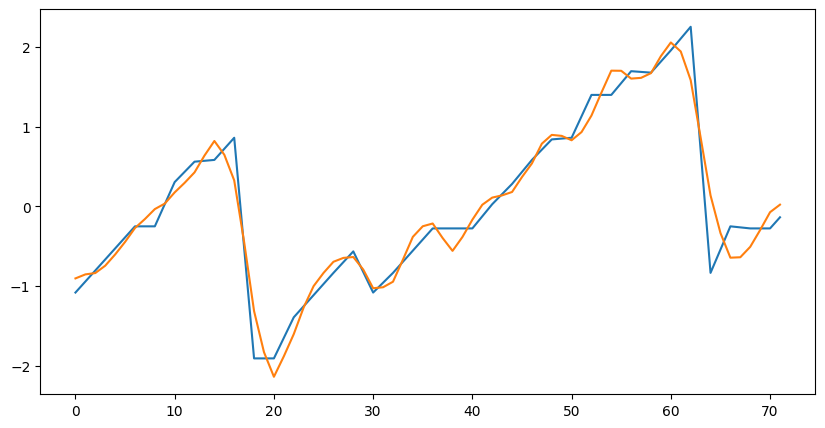

In [7]:
#retrain best model
best_params = {'n_filters': 32, 'kernel_size': 7, 'lr': 0.0012663334199774063, 'weight_decay': 0.00011973250338110865, 'batch_size': 200}
best_model = CNN1DAutoencoder(in_channels=C, input_length=L, n_filters=best_params['n_filters'], kernel_size=best_params['kernel_size'], latent_dim=20).to(device)
best_opt = torch.optim.Adam(best_model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
criterion = nn.MSELoss(reduction='sum')
train_loader = DataLoader(full_dataset, batch_size=best_params.get('batch_size',64), shuffle=True, pin_memory=True)
losses = []
for ep in trange(50, desc='Final training'):
    train_loss = train_epoch(best_model, train_loader, best_opt, criterion)
    losses.append(train_loss)

plt.figure(figsize=(10,5))
plt.plot(losses)

# visualize reconstruction
testseq=train_dataset[np.random.randint(len(train_dataset))][0].cpu().numpy().astype(float)
plt.figure(figsize=(10,5))
plt.plot(testseq)
reconstruction = best_model(torch.tensor(testseq).unsqueeze(0).to(device).float()).detach().cpu().squeeze().numpy()
plt.plot(reconstruction)

NameError: name 'vrae_trained_12' is not defined

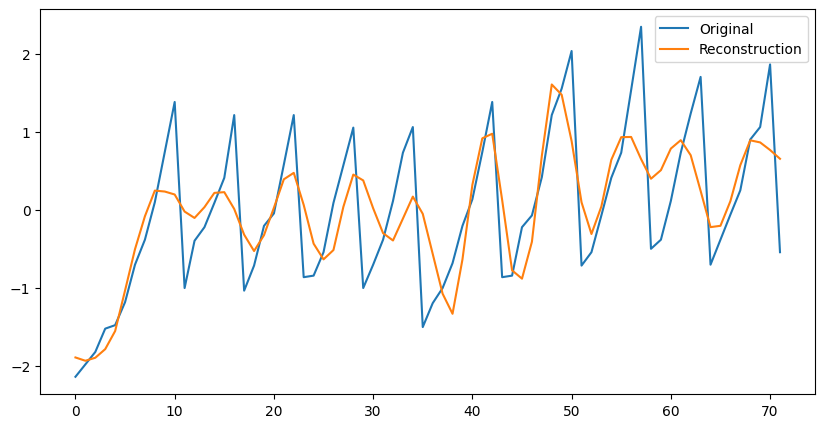

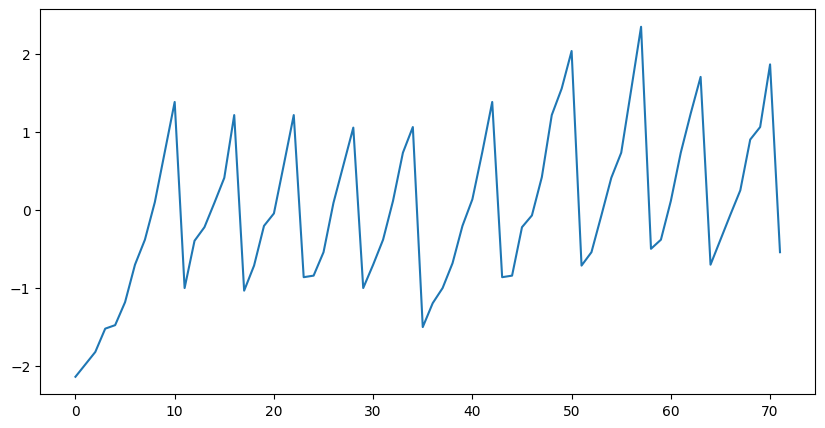

In [8]:
# testseq=train_dataset[np.random.randint(len(train_dataset))][0].cpu().numpy().astype(float)
testseq=train_dataset[15][0].cpu().numpy().astype(float)
plt.figure(figsize=(10,5))
plt.plot(testseq, label='Original')
reconstruction = best_model(torch.tensor(testseq).unsqueeze(0).to(device).float()).detach().cpu().squeeze().numpy()
plt.plot(reconstruction, label='Reconstruction')
plt.legend()

plt.figure(figsize=(10,5))
plt.plot(testseq, label='Original')
reconstruction = vrae_trained_12(torch.tensor(testseq).to(device).float().unsqueeze(1).repeat(1,200,1))[0][:,0,0].detach().cpu().squeeze().numpy()
plt.plot(reconstruction, label='Reconstruction')
plt.legend()

In [9]:
sequence_length = X_train.shape[1]
number_of_features = X_train.shape[2]

dload = './model_save' #model save directory
latent_length = 12
hidden_size = 90
hidden_layer_depth = 2
batch_size = 200
learning_rate = 0.001
n_epochs = 2 #200
dropout_rate = 0.2
optimizer = 'Adam'
cuda = True
print_every=1000
clip = True
max_grad_norm=5
loss = 'MSELoss'
block = 'LSTM'

vrae_trained_12 = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_12.load(fr'C:\Users\achfr\single_cell_time_series_representation_learning\model_12.pth')

vrae_trained_12.eval()
testseq2 = test_dataset[:batch_size][0].float().permute(1, 0, 2).cuda()
outp = vrae_trained_12.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
k=160
input_seq = testseq2[:,k,0].cpu().detach().numpy()
output_seq = outp[0][:,k,0].cpu().detach().numpy()

plt.figure(figsize=(5,13/4))
plt.plot(input_seq.T, color ='black',linewidth = 2, label='input')
plt.plot(output_seq.T, color='red',linewidth = 2, label='reconstruction')
plt.xlabel('Timepoints', fontsize=14)
plt.ylabel('Normalized size', fontsize=14)
plt.title('Reconstruction of a test sequence', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\achfr\\single_cell_time_series_representation_learning\\model_12.pth'

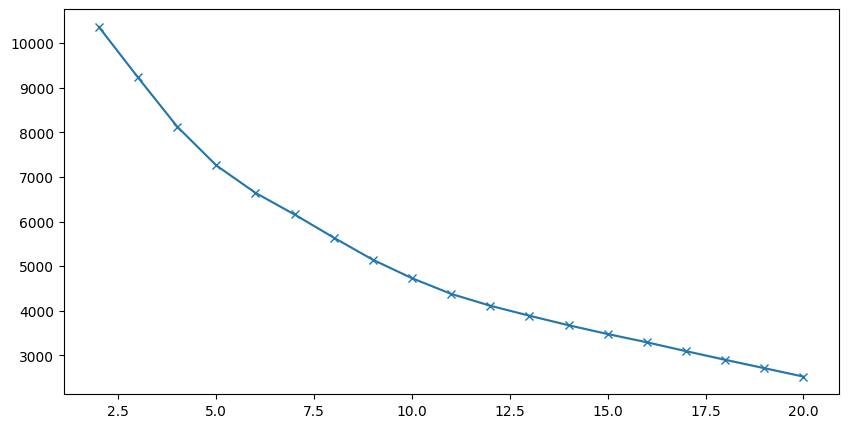

In [10]:
best_test_loss = []
best_test_loss_std = []
for latent_dim in range(2,21):
    test_loss = []
    for replicate in range(10):
        testlosses = np.load(f'model_CNN_optuna/test_losses_rep{replicate}_latent{latent_dim}.npy', allow_pickle=True)
        test_loss.append(np.min(testlosses))
    best_test_loss.append(np.mean(test_loss))
    best_test_loss_std.append(np.std(test_loss))

plt.figure(figsize=(10,5))
plt.plot(range(2,21), best_test_loss, marker='x')
plt.fill_between(range(2,21), np.array(best_test_loss) - np.array(best_test_loss_std), np.array(best_test_loss) + np.array(best_test_loss_std), alpha=0.3, edgecolor='orange', facecolor='orange')


Text(0, 0.5, 'Train Loss')

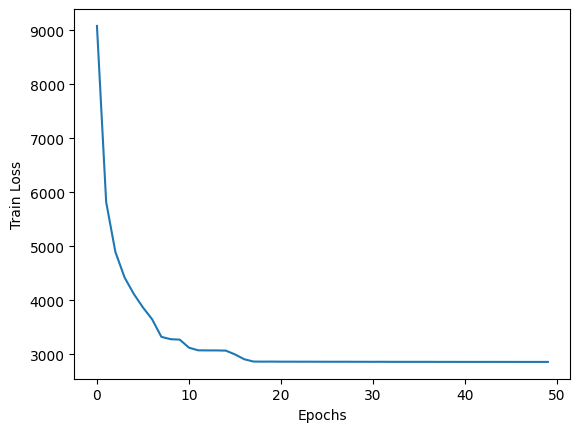

In [11]:
traincurve = np.load('C:\\Users\\achfr\\timeseries-clustering-vae\\model_CNN_optuna\\train_losses_rep1_latent20.npy', allow_pickle=True)
plt.plot(traincurve)
plt.xlabel('Epochs')
plt.ylabel('Train Loss')

Text(0.5, 0, 'Latent Length')

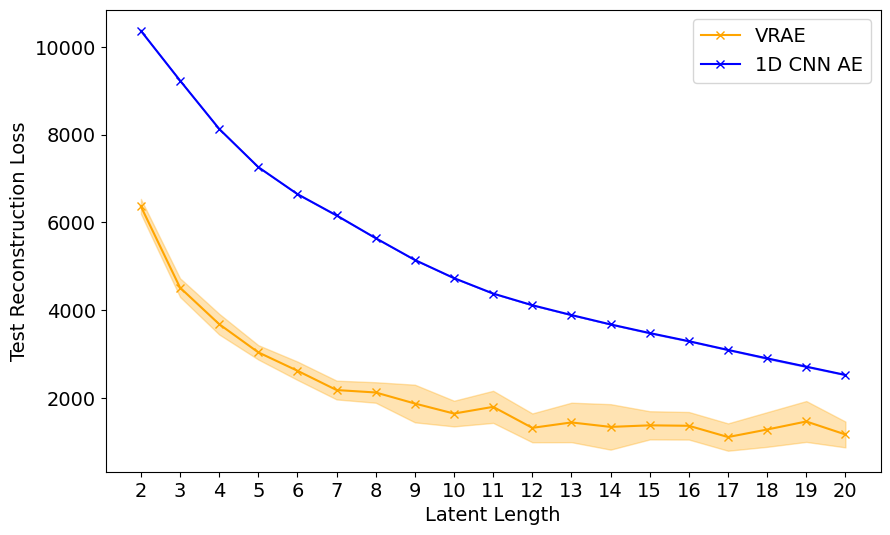

In [12]:

train_losses = {}
test_losses = {}
for latent_length in range(20,2-1,-1):
    train_losses[latent_length]=[]
    test_losses[latent_length]=[]
    for replicate in range(10):
        train_losses[latent_length].append(np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\train_losses_{replicate}_{latent_length}.npy'))
        test_losses[latent_length].append(np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\test_losses_{replicate}_{latent_length}.npy'))

#### Panel 1F
randindex_karoui = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\randindex_karoui.npy', allow_pickle=True).item()
meanz_karoui_ARI = np.array([np.mean([i[0] for i in randindex_karoui[latent_length]]) for latent_length in range(20,2-1,-1)])
stdz_karoui_ARI =  np.array([np.std([i[0] for i in randindex_karoui[latent_length]]) for latent_length in range(20,2-1,-1)])

plt.rcParams.update({'font.size': 14})
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xticks(range(20,2-1,-1))

ax2 = ax1#.twinx()
meanz_test = np.array([np.mean([np.min(i) for i in test_losses[latent_length]]) for latent_length in range(20,2-1,-1)])
stdz_test =  np.array([np.std([np.min(i) for i in test_losses[latent_length]]) for latent_length in range(20,2-1,-1)])
ax2.plot(range(20,2-1,-1), meanz_test, label='VRAE', marker = 'x', color = 'orange')
ax2.set_ylabel('Test Reconstruction Loss')
ax2.fill_between(range(20,2-1,-1), meanz_test - stdz_test, meanz_test + stdz_test, alpha=0.3, edgecolor='orange', facecolor='orange')

ax2.plot(range(2,21), best_test_loss, marker='x', label='1D CNN AE', color = 'blue')
ax2.fill_between(range(2,21), np.array(best_test_loss) - np.array(best_test_loss_std), np.array(best_test_loss) + np.array(best_test_loss_std), alpha=0.3, edgecolor='blue', facecolor='blue')
plt.legend(loc='upper right')
plt.xlabel('Latent Length')

In [13]:
#### Panel 1E
df = pd.read_pickle(fr'C:\Users\achfr\OneDrive - University of Edinburgh\Compiled dataset\df_compiled_mothers_labelled_cyclefate.csv')
df_tracks= df.pivot(values=[
    'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
    'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
    'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
    'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
    'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
    'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
    index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
    columns='Time')
#### Creating dataset and splitting it into train and test sets then data augmentation
liste_x=[]
liste_y=[]

# dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
#  'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']
dataset_name_list = ['gly_control_1','gly_control_2','gly_control_3','glu_control_1','glu_control_2','gluaa_control_1','gluaa_control_2']

for exp_name in dataset_name_list:

    medium,treatment,replicate = exp_name.split('_')

    frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
    size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
    cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])

    for i in range(size_array.shape[0]):    
        size_serie =  size_array[i]
        ##fill nans missing timepoints with the mean of the previous and next timepoints
        for j in range(1,len(size_serie)-1):
            if np.isnan(size_serie[j]):
                size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])
        cyclefate_serie = cyclefate_array[i]
        ##fill nans missing timepoints with the next fate timepoint
        for j in range(len(cyclefate_serie)-1):
            if cyclefate_serie[j] == 'nan':
                cyclefate_serie[j] = cyclefate_serie[j+1]

        t_death = len(cyclefate_serie)
        if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
            t_death = np.where(cyclefate_serie != 'alive')[0][0]

        usable_data = size_serie[:min(t_death,288)]

        if len(usable_data) > 72:
            liste_x.append(usable_data)
            liste_y.append((medium,treatment,replicate,t_death))

# # pca tsne and clustering gly glu gluaa
liste_x_embed = []
liste_y_embed = []
for i in range(len(liste_x)):
    usable_data = liste_x[i]
    for j in range(0, len(usable_data) - 72 + 1, 72):
        liste_x_embed.append(usable_data[j:j+72])
        liste_y_embed.append(liste_y[i])
X_embed = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_embed))
y_embed = np.array(liste_y_embed)
medias = np.array([k[0] for k in y_embed])

embed_dataset = TensorDataset(torch.from_numpy(X_embed).to('cuda'))

In [ ]:
X_embed.shape

(6801, 72, 1)

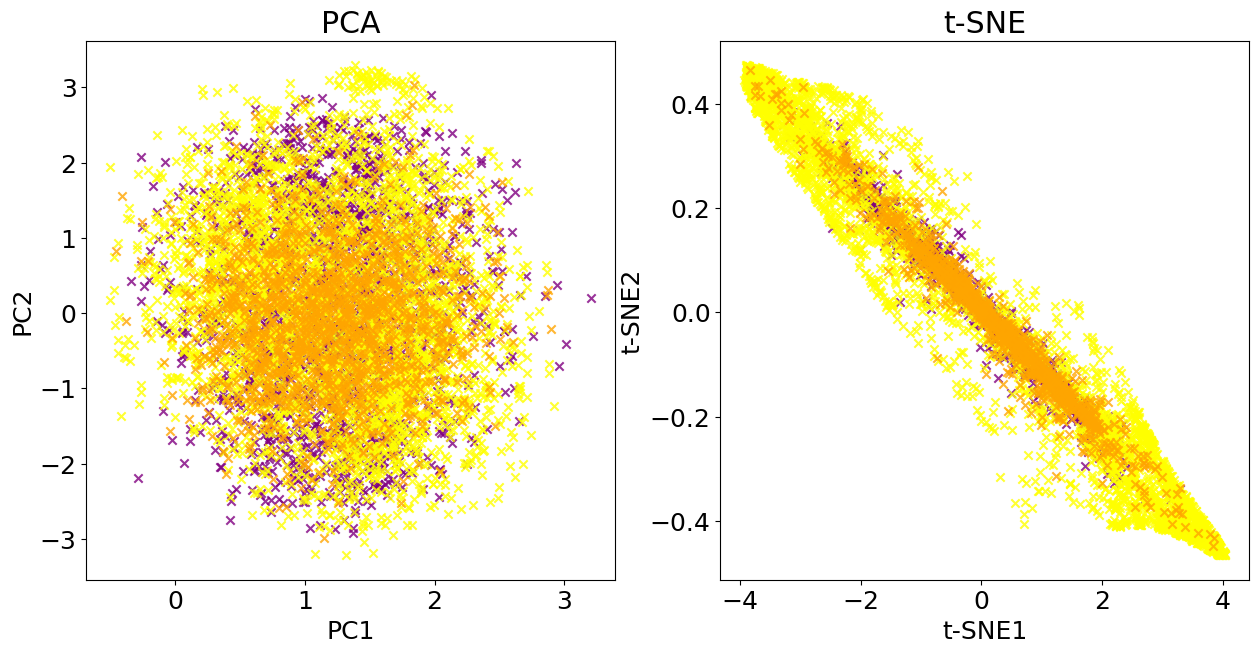

In [ ]:

projected_data = best_model.encode(torch.tensor(X_embed).float().to(device)).detach().cpu().numpy()

from sklearn.decomposition import TruncatedSVD,PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

z_run_pca = TruncatedSVD(n_components=10).fit_transform(projected_data)

z_run_tsne = TSNE(perplexity=80, min_grad_norm=1E-12, n_iter=300).fit_transform(projected_data)

plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

colors = ['purple', 'yellow', 'orange']
for i,media in enumerate(['gluaa','gly','glu']):
    ax[0].scatter(z_run_pca[medias == media, 0], z_run_pca[medias == media, 1], color=colors[i], label=media,marker='x',alpha=0.8)
    ax[1].scatter(z_run_tsne[medias == media, 0], z_run_tsne[medias == media, 1], color=colors[i], label=media,marker='x',alpha=0.8)


ax[0].set_title('PCA')
ax[1].set_title('t-SNE')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
# plt.legend()

In [25]:
np.save("cnnembedpca",z_run_pca)
np.save("cnnembedtsne",z_run_tsne)
np.save("cnnembedmedia",medias)

In [20]:
medias.shape

(6801,)

In [ ]:
import sys
vrae_path = r'C:\Users\achfr\timeseries-clustering-vae'
if vrae_path not in sys.path:
    sys.path.append(vrae_path)
from vrae.vrae import VRAE
from vrae.utils import *
import numpy as np
import torch
import pandas as pd
import plotly
from torch.utils.data import TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import pickle

import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tqdm
import optuna

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# predictions = {'cip': [], 'tet': [], 'ciptet': []}
# probs = {'cip': [], 'tet': [], 'ciptet': []}
# y_true_dict = {}

metrics_dict={}
for task in ['cip', 'tet', 'ciptet']:
    PROCESSED_DATA_DIR = fr'C:\Users\achfr\timeseries-clustering-vae\cluster_train\to_import\\'

    with open(PROCESSED_DATA_DIR + f"X_{task}_full.pkl", 'rb') as f:
        X_train_full = np.array(pickle.load(f))
    X_train_full = best_model.encode(torch.tensor(X_train_full[:,:,np.newaxis]).float().to(device)).detach().cpu().numpy()

    with open(PROCESSED_DATA_DIR + f"y_{task}_full.pkl", 'rb') as f:
        y_train_full = np.array(pickle.load(f))

    metrics=[[],[],[],[],[],[]]
    stratified_cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print(X_train_full.shape, y_train_full.shape)
    for train_index, test_index in stratified_cv.split(X_train_full, y_train_full):
        X_train, X_test = X_train_full[train_index], X_train_full[test_index]
        y_train, y_test = y_train_full[train_index], y_train_full[test_index]

        dataloader = torch.utils.data.DataLoader(
            TensorDataset(torch.tensor(X_train).float().to(device), torch.tensor(y_train).to(device)), 
            batch_size=50, 
            shuffle=True)

        test_dataloader = torch.utils.data.DataLoader(
            TensorDataset(torch.tensor(X_test).float().to(device), torch.tensor(y_test).to(device)), 
            batch_size=50,
            shuffle=False)

        model = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(20,10), max_iter=2000, random_state=42)

        # train model
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_true = y_test.tolist()
        y_probs = model.predict_proba(X_test)[:, 1]

        metrics[0].append(accuracy_score(y_pred=y_pred, y_true=y_true))
        metrics[1].append(roc_auc_score(y_true, y_probs))
        precision, recall, _ = precision_recall_curve(y_true, y_probs)
        metrics[2].append(auc(recall, precision))
        metrics[3].append(precision_score(y_true, y_pred, zero_division=0))
        metrics[4].append(recall_score(y_true, y_pred, zero_division=0))
        metrics[5].append(f1_score(y_true, y_pred, zero_division=0))

    metrics_dict[task] = {
        'accuracy': (np.mean(metrics[0]), np.std(metrics[0])),
        'precision': (np.mean(metrics[3]), np.std(metrics[3])),
        'recall': (np.mean(metrics[4]), np.std(metrics[4])),
        'f1': (np.mean(metrics[5]), np.std(metrics[5])),
        'auroc': (np.mean(metrics[1]), np.std(metrics[1])),
        'auprc': (np.mean(metrics[2]), np.std(metrics[2]))
    }

(1178, 20) (1178,)
(1124, 20) (1124,)
(1121, 20) (1121,)


In [ ]:
metrics_dict

{'cip': {'accuracy': (0.7920519293184277, 0.03219440012569679),
  'precision': (0.8385234869153402, 0.026910347121786936),
  'recall': (0.8390728476821192, 0.041716887412759154),
  'f1': (0.8382073175841287, 0.026942504240208963),
  'auroc': (0.8569960704741988, 0.03789199525389912),
  'auprc': (0.903512902146008, 0.029264826572684272)},
 'tet': {'accuracy': (0.7259563492063492, 0.03340743935537705),
  'precision': (0.7548423674281851, 0.036553615488612065),
  'recall': (0.8381357649442756, 0.04174843803689256),
  'f1': (0.7930547236388616, 0.023552531125787906),
  'auroc': (0.7621148743185218, 0.03752549029323205),
  'auprc': (0.8096771927228599, 0.03150790597874177)},
 'ciptet': {'accuracy': (0.7644642857142858, 0.024771918762656935),
  'precision': (0.7832445997692179, 0.014901782216152402),
  'recall': (0.8615602836879432, 0.02828191574543504),
  'f1': (0.8204604947145677, 0.020181927421766038),
  'auroc': (0.8159105273314999, 0.0312525176506805),
  'auprc': (0.8554866734309072, 0.